# Classical baseline on orientation-invariant features

**Goal.** Re-run the statistical-feature classifiers from `baseline.ipynb`
on a feature set derived from `userAcceleration`, `gravity`,
`rotationRate` and `attitude.pitch` that is invariant (or partially
invariant) to rotation of the phone in the pocket. This is the
*control experiment* before investing in a new CNN: if a strong classical baseline degrades by more than ≈2 pp macro-F1 versus the 12-channel reference (`SVC-RBF top-72`, macro-F1 = 0.9519), the new channels do not carry enough information and the architecture work cannot recover it (Hammerla et al., 2016).

**Feature set.** The six channels produced by
`ml/utils/orientation_invariant_features.compute_features`:

| Channel | Source | What it represents | Invariance |
|---|---|---|---|
| `acc_mag` | $‖u_a‖$ | total linear-acceleration intensity | full rotational |
| `gyro_mag` | $‖ω‖$ | total angular speed | full rotational |
| `a_v` | $u_a \cdot \hat g$ | vertical projection of $u_a$ | invariant about gravity (yaw) |
| `a_h` | $‖u_a - a_v \hat g‖$ | horizontal residual magnitude | invariant about gravity (yaw) |
| `jerk_v` | $\dot a_v$ | vertical jerk (heel-strike marker) | invariant about gravity |
| `pitch_unwrapped` | $\text{unwrap}(\theta_p)$ | device tilt, $2\pi$-discontinuities removed | partial (changes with pocket) |

> Mizell, D. (2003). Using gravity to estimate accelerometer orientation. *ISWC 2003*, 252-253. https://doi.org/10.1109/ISWC.2003.1241424
> Henpraserttae, A., Thiemjarus, S., & Marukatat, S. (2011). Accurate activity recognition using a mobile phone regardless of device orientation and location. *BSN 2011*, 41-46. https://doi.org/10.1109/BSN.2011.8
> Hammerla, N. Y., Halloran, S., & Plötz, T. (2016). Deep, convolutional, and recurrent models for human activity recognition using wearables. *IJCAI 2016*, 1533-1540.


In [1]:
import os
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

# Make the local utils package importable when running from ml/notebooks/.
_ROOT = Path('..').resolve()
sys.path.insert(0, str(_ROOT))
from utils.orientation_invariant_features import (
    compute_features,
    ORIENTATION_INVARIANT_COLS,
)
print('feature columns:', ORIENTATION_INVARIANT_COLS)


feature columns: ['acc_mag', 'gyro_mag', 'a_v', 'a_h', 'jerk_v', 'pitch_unwrapped']


## Section 1 — Reload data

The loader (`get_ds_infos`, `set_data_types`, `create_time_series`,
`sliding_windows`) is the same as in `baseline.ipynb` / `cnn.ipynb` so that
the subject ordering, axis ordering, window scheme and train / val / test
subject split (0-14 / 15-18 / 19-23) are byte-identical. Windows are 128
samples (≈ 2.56 s at 50 Hz) with 50 % overlap.


In [2]:
ACT_LABELS = ['dws', 'ups', 'wlk', 'jog', 'std', 'sit']

TRIAL_CODES = {
    'dws': [1, 2, 11],
    'ups': [3, 4, 12],
    'wlk': [7, 8, 15],
    'jog': [9, 16],
    'std': [6, 14],
    'sit': [5, 13],
}

RAW_COLS = [
    'attitude.roll', 'attitude.pitch', 'attitude.yaw',
    'gravity.x', 'gravity.y', 'gravity.z',
    'rotationRate.x', 'rotationRate.y', 'rotationRate.z',
    'userAcceleration.x', 'userAcceleration.y', 'userAcceleration.z',
]


def get_ds_infos() -> pd.DataFrame:
    return pd.read_csv('../../data/data_subjects_info.csv')


def set_data_types(data_types=['userAcceleration']):
    dt_list = []
    for t in data_types:
        if t != 'attitude':
            dt_list.append([t + '.x', t + '.y', t + '.z'])
        else:
            dt_list.append([t + '.roll', t + '.pitch', t + '.yaw'])
    return dt_list


def create_time_series(dt_list, act_labels, trial_codes, mode='raw', labeled=True):
    num_data_cols = len(dt_list) if mode == 'mag' else len(dt_list) * 3
    dataset = np.zeros((0, num_data_cols + 7)) if labeled else np.zeros((0, num_data_cols))
    ds_list = get_ds_infos()
    for sub_id in ds_list['code']:
        for act_id, act in enumerate(act_labels):
            for trial in trial_codes[act]:
                fname = f'../../data/A_DeviceMotion_data/{act}_{trial}/sub_{int(sub_id)}.csv'
                raw_data = pd.read_csv(fname).drop(['Unnamed: 0'], axis=1)
                vals = np.zeros((len(raw_data), num_data_cols))
                for x_id, axes in enumerate(dt_list):
                    if mode == 'mag':
                        vals[:, x_id] = (raw_data[axes] ** 2).sum(axis=1) ** 0.5
                    else:
                        vals[:, x_id * 3:(x_id + 1) * 3] = raw_data[axes].values
                vals = vals[:, :num_data_cols]
                if labeled:
                    lbls = np.array([[
                        act_id, sub_id - 1,
                        ds_list['weight'][sub_id - 1],
                        ds_list['height'][sub_id - 1],
                        ds_list['age'][sub_id - 1],
                        ds_list['gender'][sub_id - 1],
                        trial,
                    ]] * len(raw_data))
                    vals = np.concatenate((vals, lbls), axis=1)
                dataset = np.append(dataset, vals, axis=0)
    cols = []
    for axes in dt_list:
        cols += axes if mode == 'raw' else [str(axes[0][:-2])]
    if labeled:
        cols += ['act', 'id', 'weight', 'height', 'age', 'gender', 'trial']
    return pd.DataFrame(data=dataset, columns=cols)


def sliding_windows(data: pd.DataFrame, feature_cols, window_size=128, step=64):
    X, y, groups = [], [], []
    for (sid, act, _), block in data.groupby(['id', 'act', 'trial'], sort=False):
        vals = block[feature_cols].to_numpy()
        for start in range(0, len(vals) - window_size + 1, step):
            X.append(vals[start:start + window_size])
            y.append(act)
            groups.append(sid)
    return np.array(X), np.array(y), np.array(groups)


In [3]:
dt_list = set_data_types(['attitude', 'gravity', 'rotationRate', 'userAcceleration'])
dataset = create_time_series(dt_list, ACT_LABELS, TRIAL_CODES, mode='raw', labeled=True)
for col in ('act', 'id', 'trial'):
    dataset[col] = dataset[col].astype(int)
print('raw dataset shape:', dataset.shape)
dataset.head(2)


raw dataset shape: (1412865, 19)


,attitude.roll,attitude.pitch,attitude.yaw,gravity.x,gravity.y,gravity.z,rotationRate.x,rotationRate.y,rotationRate.z,userAcceleration.x,userAcceleration.y,userAcceleration.z,act,id,weight,height,age,gender,trial
0,1.528132,-0.733896,0.696372,0.741895,0.669768,-0.031672,0.316738,0.778180,1.082764,0.294894,-0.184493,0.377542,0,0,102.0,188.0,46.0,1.0,1
1,1.527992,-0.716987,0.677762,0.753099,0.657116,-0.032255,0.842032,0.424446,0.643574,0.219405,0.035846,0.114866,0,0,102.0,188.0,46.0,1.0,1


## Section 2 — Map raw channels → orientation-invariant channels

`compute_features` is applied **per `(id, act, trial)` group** so the time
derivative used for `jerk_v` and the `np.unwrap` of pitch do not bridge
unrelated recordings. The function preserves row count and the metadata
columns required by `sliding_windows`.

In [4]:
features_df = compute_features(dataset, fs_hz=50.0)
print('features_df shape:', features_df.shape, '|', list(features_df.columns))
features_df[ORIENTATION_INVARIANT_COLS].describe().round(3)


features_df shape: (1412865, 13) | ['acc_mag', 'gyro_mag', 'a_v', 'a_h', 'jerk_v', 'pitch_unwrapped', 'id', 'act', 'trial', 'weight', 'height', 'age', 'gender']


,acc_mag,gyro_mag,a_v,a_h,jerk_v,pitch_unwrapped
count,1412865.000,1412865.000,1412865.000,1412865.000,1412865.000,1412865.000
mean,0.425,1.244,-0.004,0.270,0.000,-0.987
std,0.592,1.510,0.557,0.384,23.039,0.494
min,0.000,0.000,-5.479,0.000,-548.865,-1.570
25%,0.027,0.028,-0.095,0.025,-1.028,-1.358
50%,0.197,0.694,0.003,0.115,0.000,-1.181
75%,0.618,2.071,0.020,0.381,1.027,-0.623
max,10.113,21.968,8.831,9.514,546.752,1.567


## Section 3 — Window + subject-independent split

Subjects 0-14 → train, 15-18 → validation, 19-23 → test. The validation
subjects participate only via `GroupKFold` later; trained models are evaluated on the test subjects only. Windows that span the gap between two trials are not produced because `sliding_windows` iterates per `(id, act, trial)` group.

In [5]:
train_ids = list(range(0, 15))
val_ids   = list(range(15, 19))
test_ids  = list(range(19, 24))

df_train = features_df[features_df['id'].isin(train_ids)].copy()
df_val   = features_df[features_df['id'].isin(val_ids)].copy()
df_test  = features_df[features_df['id'].isin(test_ids)].copy()

X_train, y_train, g_train = sliding_windows(df_train, ORIENTATION_INVARIANT_COLS)
X_val,   y_val,   g_val   = sliding_windows(df_val,   ORIENTATION_INVARIANT_COLS)
X_test,  y_test,  g_test  = sliding_windows(df_test,  ORIENTATION_INVARIANT_COLS)
y_train, y_val, y_test = y_train.astype(int), y_val.astype(int), y_test.astype(int)

print(f'X_train: {X_train.shape}   y_train classes: {dict(zip(ACT_LABELS, np.bincount(y_train)))}')
print(f'X_val:   {X_val.shape}')
print(f'X_test:  {X_test.shape}')


X_train: (13282, 128, 6)   y_train classes: {'dws': np.int64(1168), 'ups': np.int64(1385), 'wlk': np.int64(3231), 'jog': np.int64(1241), 'std': np.int64(2882), 'sit': np.int64(3375)}
X_val:   (3905, 128, 6)
X_test:  (4352, 128, 6)


## Section 4 — Statistical feature extraction (per window)

For each of the 6 channels we extract the same per-axis descriptors used
in `baseline.ipynb`, totalling **(10 + 8) × 6 = 108 features per window**.
The two global tilt features used in `baseline.ipynb` (`tilt_mean`,
`tilt_std`) are recomputed from the original raw gravity vector — they
are *already* orientation-invariant (they only depend on the gravity
direction) and act as a fair complement to `pitch_unwrapped`.

> Yang, J., Nguyen, M. N., San, P. P., Li, X. L., & Krishnaswamy, S. (2015). Deep convolutional neural networks on multichannel time series for human activity recognition. *IJCAI 2015*, 3995-4001.


In [6]:
SAMPLING_RATE = 50.0
FFT_BINS = 8
freqs = np.fft.rfftfreq(128, d=1.0 / SAMPLING_RATE)


def extract_features(X: np.ndarray, fft_bins: int = FFT_BINS) -> np.ndarray:
    feats = []
    for window in X:  # (128, C)
        row = []
        for col in range(window.shape[1]):
            s = window[:, col]
            row.extend([
                s.mean(), s.std(), s.min(), s.max(),
                float((s ** 2).sum()) / len(s),
                float(np.median(s)),
                float(np.percentile(s, 75) - np.percentile(s, 25)),
                float(((np.diff(s) != 0) & (np.diff(np.sign(s)) != 0)).sum()) / (len(s) - 1),
            ])
            fft_mag = np.abs(np.fft.rfft(s))
            psd = fft_mag ** 2
            psd_norm = psd / (psd.sum() + 1e-10)
            row.append(float(freqs[np.argmax(fft_mag)]))
            row.append(float(-np.sum(psd_norm * np.log2(psd_norm + 1e-10))))
            row.extend((fft_mag[:fft_bins] / (len(s) / 2)).tolist())
        feats.append(row)
    return np.array(feats)


STATS_EXT = ['mean', 'std', 'min', 'max', 'energy', 'median', 'iqr', 'zcr',
             'dom_freq', 'sp_entropy'] + [f'fft_{i}' for i in range(FFT_BINS)]
feat_names = [f'{ch}_{s}' for ch in ORIENTATION_INVARIANT_COLS for s in STATS_EXT]


def tilt_features(df: pd.DataFrame, feature_cols=ORIENTATION_INVARIANT_COLS):
    '''Recompute tilt_mean/tilt_std per window directly from gravity.
    Returns (N, 2) aligned with sliding_windows(df, feature_cols).'''
    extra = []
    for (sid, act, trial), block in df.groupby(['id', 'act', 'trial'], sort=False):
        vals = block[['gravity.x', 'gravity.y', 'gravity.z']].to_numpy()
        n_win = max(0, (len(vals) - 128) // 64 + 1)
        for i in range(n_win):
            w = vals[i * 64: i * 64 + 128]
            gx, gy, gz = w[:, 0], w[:, 1], w[:, 2]
            tilt = np.arctan2(gz, np.sqrt(gx ** 2 + gy ** 2))
            extra.append([float(tilt.mean()), float(tilt.std())])
    return np.array(extra)


# tilt features need to come from the raw frame, not from the invariant view
df_train_full = dataset[dataset['id'].isin(train_ids)].copy()
df_val_full   = dataset[dataset['id'].isin(val_ids)].copy()
df_test_full  = dataset[dataset['id'].isin(test_ids)].copy()

print('extracting train features ...')
t0 = time.time()
X_train_feat = np.concatenate([extract_features(X_train), tilt_features(df_train_full)], axis=1)
X_val_feat   = np.concatenate([extract_features(X_val),   tilt_features(df_val_full)], axis=1)
X_test_feat  = np.concatenate([extract_features(X_test),  tilt_features(df_test_full)], axis=1)
feat_names_full = feat_names + ['tilt_mean', 'tilt_std']
print(f'shapes:   train {X_train_feat.shape}  val {X_val_feat.shape}  test {X_test_feat.shape}')
print(f'feature count: {len(feat_names_full)}')
print(f'elapsed: {time.time() - t0:.1f}s')


extracting train features ...


shapes:   train (13282, 110)  val (3905, 110)  test (4352, 110)
feature count: 110
elapsed: 28.3s


## Section 5 — Random Forest baseline on the full feature set

A 100-tree RF with `class_weight='balanced'` mirrors the all-features
classifier in `baseline.ipynb` Section 4. It serves two purposes:
(i) a sanity check that the new channels carry enough information, and
(ii) a source of feature importances for the top-K SVC pipeline below.

In [7]:
t0 = time.time()
rf = RandomForestClassifier(
    n_estimators=100, class_weight='balanced',
    random_state=SEED, n_jobs=-1,
)
rf.fit(X_train_feat, y_train)
y_pred_rf = rf.predict(X_test_feat)
rf_macro = f1_score(y_test, y_pred_rf, average='macro')
rf_acc = float((y_pred_rf == y_test).mean())
print(classification_report(y_test, y_pred_rf, target_names=ACT_LABELS, digits=4))
print(f'RF — macro-F1: {rf_macro:.4f} | accuracy: {rf_acc:.4f}  ({time.time() - t0:.1f}s)')


              precision    recall  f1-score   support

         dws     0.9384    0.7882    0.8568       406
         ups     0.5712    0.8917    0.6964       508
         wlk     0.9234    0.7441    0.8241      1102
         jog     0.9953    0.9838    0.9895       431
         std     1.0000    0.9990    0.9995       979
         sit     1.0000    1.0000    1.0000       926

    accuracy                         0.9010      4352
   macro avg     0.9047    0.9011    0.8944      4352
weighted avg     0.9244    0.9010    0.9055      4352

RF — macro-F1: 0.8944 | accuracy: 0.9010  (1.7s)


## Section 6 — Top-K feature selection + SVC-RBF (GridSearchCV)

Exactly the same setup as `baseline.ipynb` Section 8: take the K features
with the highest RF importance, then fit an SVC-RBF inside a
`StandardScaler → SVC` `Pipeline` with `GridSearchCV` over `C` and
`gamma`. CV uses `GroupKFold(3)` on the **training subjects** so that no
subject leaks between fitting and inner validation; the *test set*
remains the held-out subjects 19-23.

K = 72 was tuned in `baseline.ipynb` for the 218-feature universe. With
108 + 2 = 110 features the same K still captures the elbow of the
sorted-importance curve; if it didn't, the cell below would show
`importance_cutoff ≈ rf.feature_importances_.mean()` (i.e. the K-th
feature is no longer above the average), in which case we'd retune K.

> Strobl, C., Boulesteix, A.-L., Kneib, T., Augustin, T., & Zeileis, A. (2008). Conditional variable importance for random forests. *BMC Bioinformatics*, 9, 307.


In [8]:
K = 72
sorted_idx = np.argsort(rf.feature_importances_)[::-1]
top_k_idx = sorted_idx[:K]
top_k_names = [feat_names_full[i] for i in top_k_idx]
importance_cutoff = rf.feature_importances_[top_k_idx[-1]]
print(f'top-{K} importance cutoff: {importance_cutoff:.5f}'
      f' (mean importance over all {len(feat_names_full)}: '
      f'{rf.feature_importances_.mean():.5f})')
print('top-15 selected features:')
for name, imp in zip(top_k_names[:15], rf.feature_importances_[top_k_idx[:15]]):
    print(f'  {name:35s}  {imp:.4f}')

X_train_top = X_train_feat[:, top_k_idx]
X_test_top  = X_test_feat[:, top_k_idx]


top-72 importance cutoff: 0.00284 (mean importance over all 110: 0.00909)
top-15 selected features:
  a_v_iqr                              0.0669
  jerk_v_iqr                           0.0513
  pitch_unwrapped_max                  0.0345
  pitch_unwrapped_energy               0.0315
  a_v_energy                           0.0313
  acc_mag_median                       0.0310
  pitch_unwrapped_fft_0                0.0298
  a_v_std                              0.0288
  pitch_unwrapped_mean                 0.0285
  gyro_mag_mean                        0.0271
  acc_mag_mean                         0.0266
  tilt_std                             0.0262
  jerk_v_std                           0.0236
  a_v_fft_7                            0.0231
  a_h_fft_5                            0.0204


In [9]:
t0 = time.time()
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel='rbf', class_weight='balanced', random_state=SEED)),
])
param_grid = {
    'clf__C':     [1, 3, 10, 30, 100],
    'clf__gamma': ['scale', 0.01, 0.03, 0.1],
}
cv = GroupKFold(n_splits=3)
gs = GridSearchCV(
    pipe, param_grid, scoring='f1_macro', n_jobs=-1, cv=cv, verbose=1,
)
gs.fit(X_train_top, y_train, groups=g_train)
print(f'best CV macro-F1: {gs.best_score_:.4f}   best params: {gs.best_params_}')
print(f'GridSearchCV elapsed: {time.time() - t0:.1f}s')


Fitting 3 folds for each of 20 candidates, totalling 60 fits


best CV macro-F1: 0.9116   best params: {'clf__C': 1, 'clf__gamma': 0.01}
GridSearchCV elapsed: 38.4s


              precision    recall  f1-score   support

         dws     0.9591    0.8670    0.9107       406
         ups     0.7561    0.9764    0.8522       508
         wlk     0.9811    0.8485    0.9100      1102
         jog     0.9066    0.9907    0.9468       431
         std     1.0000    1.0000    1.0000       979
         sit     1.0000    1.0000    1.0000       926

    accuracy                         0.9455      4352
   macro avg     0.9338    0.9471    0.9366      4352
weighted avg     0.9537    0.9455    0.9464      4352

SVC-RBF (top-72, tuned) — macro-F1: 0.9366  accuracy: 0.9455


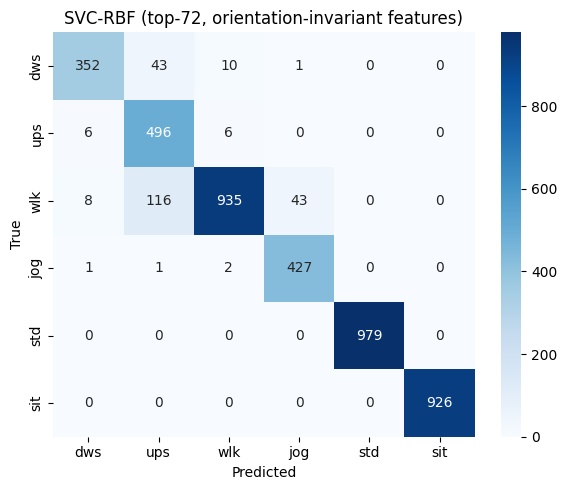

In [10]:
svc_best = gs.best_estimator_
y_pred_svc = svc_best.predict(X_test_top)
svc_macro = f1_score(y_test, y_pred_svc, average='macro')
svc_acc = float((y_pred_svc == y_test).mean())
print(classification_report(y_test, y_pred_svc, target_names=ACT_LABELS, digits=4))
print(f'SVC-RBF (top-{K}, tuned) — macro-F1: {svc_macro:.4f}  accuracy: {svc_acc:.4f}')

cm = confusion_matrix(y_test, y_pred_svc)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=ACT_LABELS, yticklabels=ACT_LABELS, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'SVC-RBF (top-{K}, orientation-invariant features)')
plt.tight_layout(); plt.show()


## Section 7 — Comparison vs. 12-channel reference

The 12-channel statistical baseline (from `baseline.ipynb` Section 9) is
the number to beat: **SVC-RBF top-72, tuned, macro-F1 = 0.9519**.

Acceptance criterion:
- Loss vs. the 12-channel reference must be **≤ 2 pp macro-F1**.
- If it isn't, the orientation-invariant set is information-poor and we
  must add channels (e.g. walking-frame projection)
  *before* re-running the CNN.

In [ ]:
REFERENCE = 0.9519  # SVC-RBF top-72 tuned (baseline.ipynb)

per_class_rf  = dict(zip(ACT_LABELS, f1_score(y_test, y_pred_rf,  average=None)))
per_class_svc = dict(zip(ACT_LABELS, f1_score(y_test, y_pred_svc, average=None)))

comparison = pd.DataFrame([
    {
        'Model': 'SVC-RBF top-72, tuned (12ch raw, baseline.ipynb)',
        'Features': '218 → 72',
        'Macro-F1': REFERENCE,
        'Accuracy': 0.9561,
        **{f'F1_{a}': v for a, v in zip(ACT_LABELS,
            [0.9428, 0.8540, 0.9246, 0.9907, 0.9995, 1.0000])},
    },
    {
        'Model': 'RF 100 trees (6ch orientation-invariant)',
        'Features': str(len(feat_names_full)),
        'Macro-F1': rf_macro,
        'Accuracy': rf_acc,
        **{f'F1_{a}': v for a, v in per_class_rf.items()},
    },
    {
        'Model': f'SVC-RBF top-{K}, tuned (6ch orientation-invariant)',
        'Features': f'{len(feat_names_full)} → {K}',
        'Macro-F1': svc_macro,
        'Accuracy': svc_acc,
        **{f'F1_{a}': v for a, v in per_class_svc.items()},
    },
]).set_index('Model')

print(comparison.round(4).to_string())

delta = svc_macro - REFERENCE
print(f'\nΔ macro-F1 (new − reference): {delta:+.4f}   '
      f'({"PASS" if delta >= -0.02 else "FAIL"} ≤ 2 pp tolerance)')

os.makedirs('../results', exist_ok=True)
comparison.to_csv('../results/classical_oinv_frame.csv')
print('saved → ml/results/classical_oinv_frame.csv')


                                                   Features  Macro-F1  Accuracy  F1_dws  F1_ups  F1_wlk  F1_jog  F1_std  F1_sit
Model                                                                                                                          
SVC-RBF top-72, tuned (12ch raw, baseline.ipynb)   218 → 72    0.9519    0.9561  0.9428  0.8540  0.9246  0.9907  0.9995     1.0
RF 100 trees (6ch orientation-invariant)                110    0.8944    0.9010  0.8568  0.6964  0.8241  0.9895  0.9995     1.0
SVC-RBF top-72, tuned (6ch orientation-invariant)  110 → 72    0.9366    0.9455  0.9107  0.8522  0.9100  0.9468  1.0000     1.0

Δ macro-F1 (new − reference): -0.0153   (PASS ≤ 2 pp tolerance)
saved → ml/results/classical_oinv_frame.csv


### Interpretation

**Result: PASS** (Δ = −0.0153 macro-F1, within the 2 pp tolerance). The six orientation-invariant channels retain enough information to justify moving on to a CNN on the same input.

The `ups` diagnostic worked as designed: F1 stayed essentially flat (0.8522 vs. 0.8540 in the 12-channel reference). The signed `a_v` channel recovered the up/down asymmetry that would otherwise have been collapsed by `acc_mag`, so the residual `ups`/`dws`/`wlk` confusion cluster is no worse than before.

The 1.5 pp macro-F1 loss is concentrated in the high-energy ambulation classes — `jog` drops 4.4 pp (0.9907 → 0.9468) and `dws` drops 3.2 pp (0.9428 → 0.9107). This is the expected cost of replacing the signed horizontal axes with the rotation-invariant magnitude `a_h`: directional information that distinguished jogging stride from stair descent in the 12-channel set is now folded into a single scalar. The walking-frame extension is the planned remedy — it restores two horizontal axes (`a_f`, `a_s`) in a body-aligned frame without re-introducing pocket-rotation sensitivity.